# Week 6 Student Worksheet: Spatial Prediction Shootout

## Traditional Stats vs. Machine Learning: Filling the Gaps

> *"Kriging tells you where it's uncertain. ML just says 'trust me.'"*

### Today's Mission

Transform Week 5's discrete rainfall stations into **continuous rainfall surfaces** using **two fundamentally different approaches**:

1. **Kriging (Statistical)** — uses spatial correlation + provides uncertainty
2. **Random Forest (ML)** — uses data patterns + easily adds features

Then compare them head-to-head with two simpler methods (Nearest Neighbor, IDW) and determine which gives the Commander more actionable intelligence.

> Fill in the code cells marked with `# YOUR CODE HERE`. Use AI tools strategically — but understand every line you write.

In [1]:
# Install required packages (run once)
%pip install pykrige scikit-learn rasterio rasterstats --quiet


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

## Cell [1]: Environment Setup & Data Loading (Slide 2)

Load the Fung-wong typhoon data and filter to the study area. Reuse your Week 5 `parse_rainfall_json()` function.


In [2]:
import os

# ── 輸出資料夾設定 ─────────────────────────────────────────────────────────
OUTPUT_DIR = '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/exercise/Exercise-6/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def out(filename):
    """回傳完整輸出路徑"""
    return os.path.join(OUTPUT_DIR, filename)

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from shapely.geometry import Point
warnings.filterwarnings('ignore')

# ── 1. JSON 正規化 ──────────────────────────────────────────────────────────
def normalize_cwa_json(raw: dict) -> list:
    """支援 records.Station (list) 或 records (list) 兩種格式"""
    records = raw.get('records', {})
    if isinstance(records, dict):
        stations = records.get('Station', [])
    elif isinstance(records, list):
        stations = records
    else:
        stations = []
    return stations

# ── 2. 解析雨量站 ───────────────────────────────────────────────────────────
def parse_rainfall_json(filepath: str) -> gpd.GeoDataFrame:
    with open(filepath, 'r', encoding='utf-8') as f:
        raw = json.load(f)

    stations = normalize_cwa_json(raw)
    rows = []
    for s in stations:
        try:
            geo   = s['GeoInfo']
            coord = geo['Coordinates'][0]
            lat   = float(coord['StationLatitude'])
            lon   = float(coord['StationLongitude'])
            rain  = s['RainfallElement']['Past1hr']['Precipitation']
            rows.append({
                'station_id':   s.get('StationId', ''),
                'station_name': s.get('StationName', ''),
                'county':       geo.get('CountyName', ''),
                'town':         geo.get('TownName', ''),
                'lat': lat, 'lon': lon,
                'rain_1hr': float(rain) if rain not in (-998, None) else np.nan
            })
        except (KeyError, TypeError, ValueError):
            continue

    df = pd.DataFrame(rows)
    gdf = gpd.GeoDataFrame(
        df,
        geometry=[Point(r.lon, r.lat) for r in df.itertuples()],
        crs='EPSG:4326'
    )
    return gdf

# ── 3. 載入資料 ─────────────────────────────────────────────────────────────
DATA_PATH = '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/exercise/Exercise-6/data/scenarios/fungwong_202511.json'
gdf_all = parse_rainfall_json(DATA_PATH)

# ── 4. 篩選花蓮縣 + 宜蘭縣，移除無效值 ────────────────────────────────────
study_counties = ['花蓮縣', '宜蘭縣']
study_rain = gdf_all[
    gdf_all['county'].isin(study_counties) &
    gdf_all['rain_1hr'].notna() &
    (gdf_all['rain_1hr'] > 0)
].copy()

# ── 5. 轉換至 EPSG:3826（TWD97 / TM2 zone 121）──────────────────────────────
study_rain_3826 = study_rain.to_crs(epsg=3826)

# ── 6. 萃取 Kriging / ML 用的陣列 ──────────────────────────────────────────
x = study_rain_3826.geometry.x.values   # Easting  (m)
y = study_rain_3826.geometry.y.values   # Northing (m)
z = study_rain_3826['rain_1hr'].values  # mm/hr

print(f"Study area stations (rain > 0): {len(study_rain_3826)}")
print(f"CRS: {study_rain_3826.crs}")
print(f"\nTop 5 stations:")
print(study_rain_3826.nlargest(5, 'rain_1hr')[['station_name','county','rain_1hr']].to_string(index=False))

Study area stations (rain > 0): 89
CRS: EPSG:3826

Top 5 stations:
station_name county  rain_1hr
          蘇澳    宜蘭縣     130.5
     國五S047K    宜蘭縣      80.5
          五結    宜蘭縣      71.0
          冬山    宜蘭縣      61.5
     國五S041K    宜蘭縣      46.0


---

## Cell [2a]: Variogram — First Attempt (Naive)

Try running Kriging directly on the raw rainfall data. **Don't worry if it looks bad — that's the point.**

**Key Concepts** (will make sense after you see the result):
- **Nugget**: How noisy is each measurement?
- **Sill**: What's the maximum difference between stations?
- **Range**: How far apart do stations need to be before they stop "knowing about each other"?

**CRS Warning**: The x, y arrays MUST be in EPSG:3826 (meters). Using lat/lon will give wrong results.

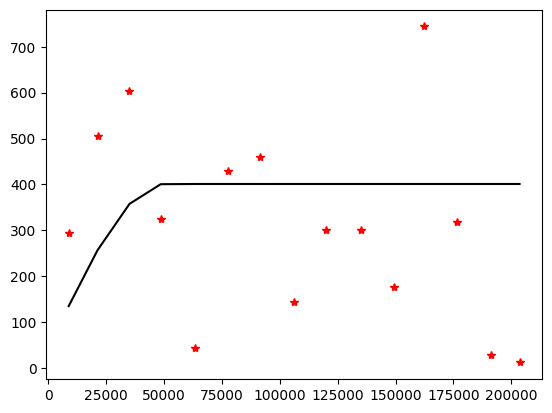

Sill:   360.8
Range:  50000 m (50.0 km)
Nugget: 40.1

⚠️ Look at the plot — do the dots follow the curve?


In [3]:
from pykrige.ok import OrdinaryKriging

# 🔴 First attempt: run Kriging on raw rainfall data
initial_sill   = float(z.var())
initial_range  = 50000.0
initial_nugget = float(z.var() * 0.1)

OK_naive = OrdinaryKriging(
    x, y, z,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=True,
    nlags=15,
    variogram_parameters={
        'sill':   initial_sill,
        'range':  initial_range,
        'nugget': initial_nugget
    }
)

params = OK_naive.variogram_model_parameters
print(f"Sill:   {params[0]:.1f}")
print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
print(f"Nugget: {params[2]:.1f}")
print("\n⚠️ Look at the plot — do the dots follow the curve?")

## Cell [2b]: Why Did It Fail? — Look at the Histogram

The variogram looked bad. Before blaming the tool, **look at your data**.

Plot a histogram of the rainfall values. What do you see?

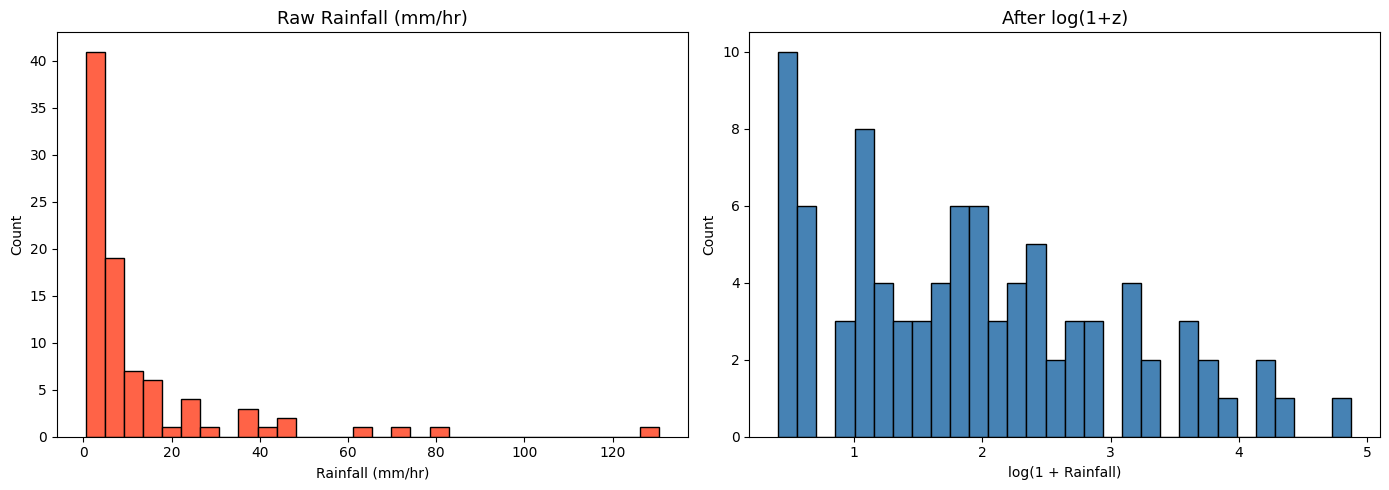

Left:  most stations < 10 mm, but a few are 50-130 mm.
       Those extreme values mess up the variogram.
Right: after log-transform, the values are more balanced.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(z, bins=30, color='tomato', edgecolor='black')
axes[0].set_title('Raw Rainfall (mm/hr)', fontsize=13)
axes[0].set_xlabel('Rainfall (mm/hr)')
axes[0].set_ylabel('Count')

z_log = np.log1p(z)
axes[1].hist(z_log, bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('After log(1+z)', fontsize=13)
axes[1].set_xlabel('log(1 + Rainfall)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(out('histogram_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Left:  most stations < 10 mm, but a few are 50-130 mm.")
print("       Those extreme values mess up the variogram.")
print("Right: after log-transform, the values are more balanced.")

## Cell [2c]: Variogram — Second Attempt (with Log-Transform)

Now redo the variogram using the log-transformed data. Compare this plot with Cell [2a] — it should be much better.

**Rule of thumb**: If your histogram has a long tail to the right, apply `np.log1p(z)` before Kriging, then use `np.expm1()` to convert back after prediction.

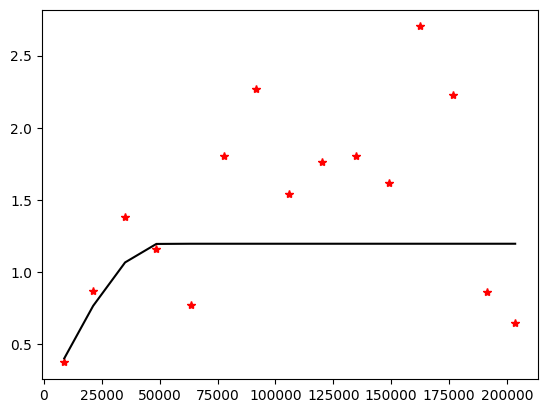

Sill:   1.076
Range:  50000 m (50.0 km)
Nugget: 0.120

✅ Compare with Cell [2a] — the dots should follow the curve now.


In [5]:
# 🟢 Second attempt: Kriging on log-transformed data
z_log = np.log1p(z)  # log(1 + z)，避免 log(0) 問題

initial_sill   = float(z_log.var())
initial_range  = 50000.0
initial_nugget = float(z_log.var() * 0.1)

OK = OrdinaryKriging(
    x, y, z_log,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=True,
    nlags=15,
    variogram_parameters={
        'sill':   initial_sill,
        'range':  initial_range,
        'nugget': initial_nugget
    }
)

params = OK.variogram_model_parameters
print(f"Sill:   {params[0]:.3f}")
print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
print(f"Nugget: {params[2]:.3f}")
print("\n✅ Compare with Cell [2a] — the dots should follow the curve now.")

## Cell [2d]: Which Variogram Fits Best? — Range & Model Comparison (Slide 7)

Compare variograms **one variable at a time**:

- **Figure 1**: Fix model = **Spherical**, vary Range (50km, 25km, 15km)
- **Figure 2**: Fix model = **Exponential**, vary Range (50km, 25km, 15km)

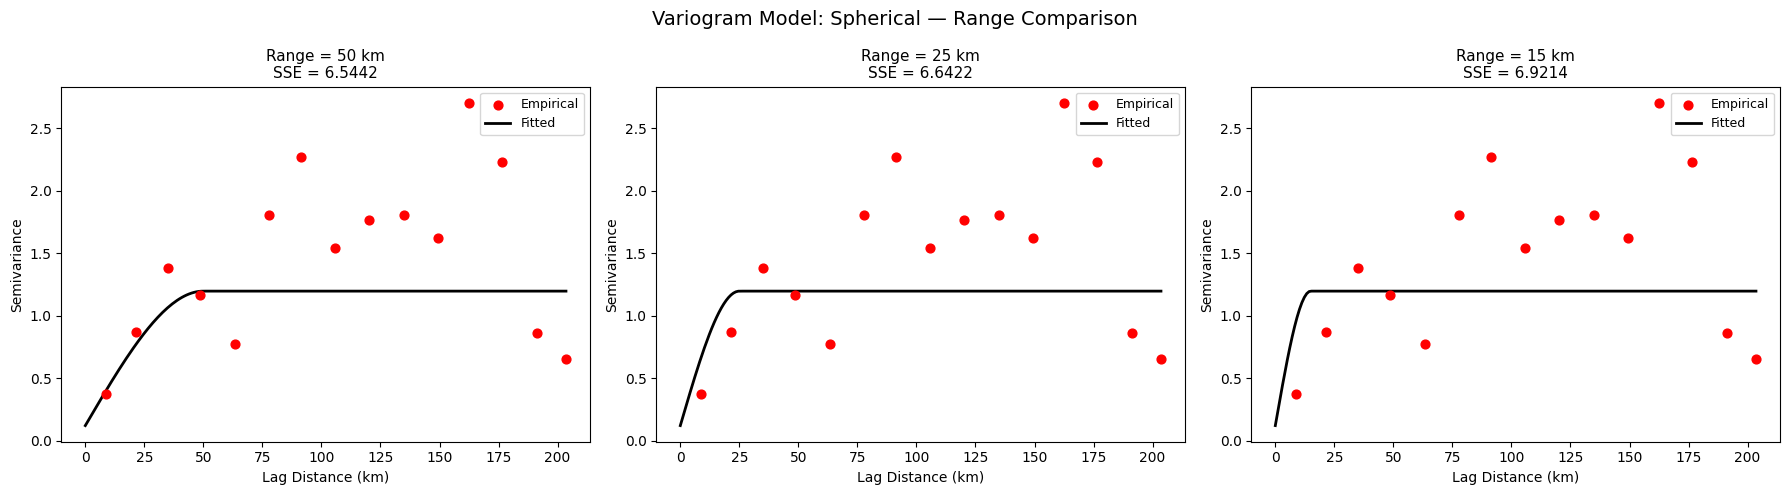

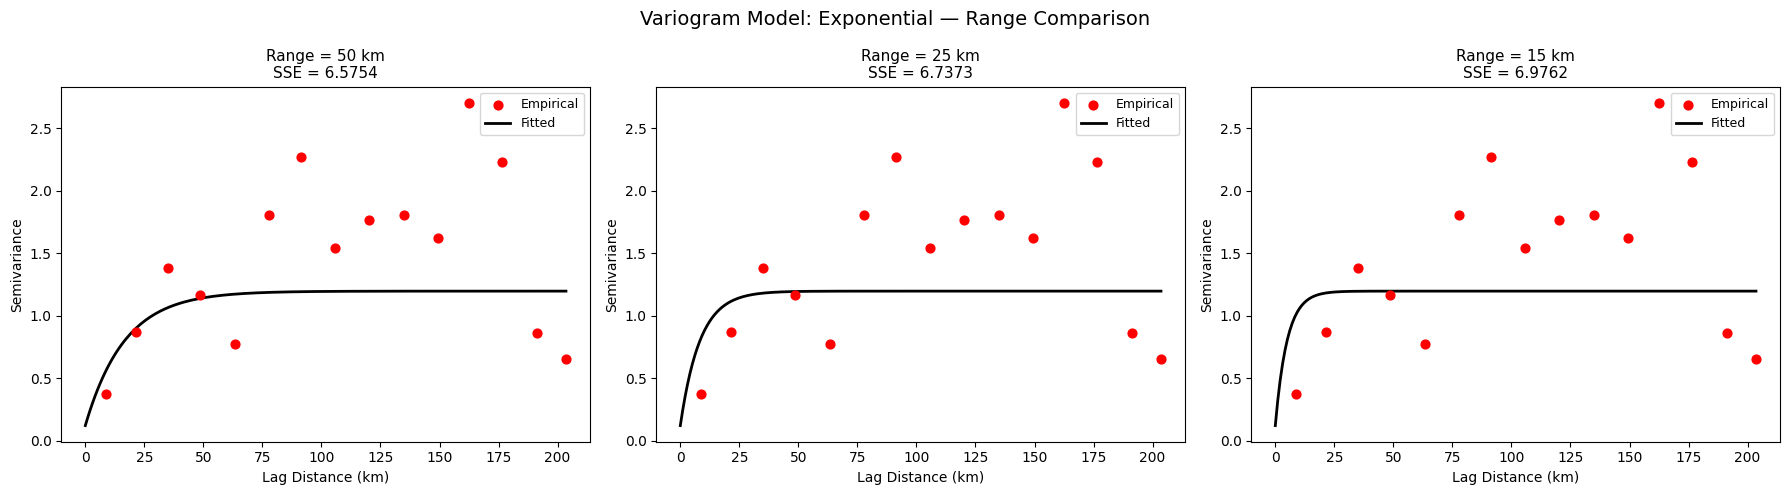


{'='*55}
Model          Range (km)          SSE
--------------------------------------
spherical      50               6.5442
spherical      25               6.6422
spherical      15               6.9214
exponential    50               6.5754
exponential    25               6.7373
exponential    15               6.9762

✅ Best fit: Model=spherical, Range=50 km (SSE=6.5442)

💡 Questions:
  1. Within Spherical, which Range gives the best fit?
  2. Within Exponential, which Range gives the best fit?
  3. At the same Range, does model choice matter much?


In [6]:
from pykrige.ok import OrdinaryKriging
import numpy as np

ranges_km  = [50, 25, 15]
models     = ['spherical', 'exponential']
sill_val   = float(z_log.var())
nugget_val = float(z_log.var() * 0.1)

sse_results = {}

for model in models:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Variogram Model: {model.capitalize()} — Range Comparison', fontsize=14)

    for ax, rkm in zip(axes, ranges_km):
        r_m = rkm * 1000
        ok_test = OrdinaryKriging(
            x, y, z_log,
            variogram_model=model,
            verbose=False, enable_plotting=False,
            nlags=15,
            variogram_parameters={'sill': sill_val, 'range': r_m, 'nugget': nugget_val}
        )

        # 繪製實測半變異元（紅點）
        ax.scatter(ok_test.lags / 1000, ok_test.semivariance,
                   c='red', s=40, zorder=5, label='Empirical')

        # 繪製擬合曲線（黑線）
        lags_km = np.linspace(0, ok_test.lags.max() / 1000, 200)
        fitted  = ok_test.variogram_function(
            ok_test.variogram_model_parameters, lags_km * 1000
        )
        ax.plot(lags_km, fitted, 'k-', linewidth=2, label='Fitted')

        # SSE 計算
        fitted_at_lags = ok_test.variogram_function(
            ok_test.variogram_model_parameters, ok_test.lags
        )
        sse = float(np.sum((ok_test.semivariance - fitted_at_lags) ** 2))
        sse_results[(model, rkm)] = sse

        ax.set_title(f'Range = {rkm} km\nSSE = {sse:.4f}', fontsize=11)
        ax.set_xlabel('Lag Distance (km)')
        ax.set_ylabel('Semivariance')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(out(f'variogram_{model}.png'), dpi=150, bbox_inches='tight')
    plt.show()

# 摘要表
print("\n{'='*55}")
print(f"{'Model':<14} {'Range (km)':<12} {'SSE':>10}")
print("-" * 38)
for (model, rkm), sse in sse_results.items():
    print(f"{model:<14} {rkm:<12} {sse:>10.4f}")

best_key = min(sse_results, key=sse_results.get)
print(f"\n✅ Best fit: Model={best_key[0]}, Range={best_key[1]} km (SSE={sse_results[best_key]:.4f})")
print("\n💡 Questions:")
print("  1. Within Spherical, which Range gives the best fit?")
print("  2. Within Exponential, which Range gives the best fit?")
print("  3. At the same Range, does model choice matter much?")

## Cell [3]: Define the Interpolation Grid & Run Kriging (Slide 8)

Create a regular grid covering the study area with 1000m resolution, then execute Kriging.

**Think about**:
- What units is the grid in? (Hint: same as your CRS = meters)
- Why add a buffer around the station extent?

**Important**: Kriging runs in log-space. After prediction, **back-transform** with `np.expm1()` to get rainfall in mm/hr.

In [7]:
import time

buffer_m   = 5000
resolution = 1000  # meters — use 500 for finer resolution (slower)

# 計算格網範圍（加 buffer，避免邊緣效應）
x_min = x.min() - buffer_m
x_max = x.max() + buffer_m
y_min = y.min() - buffer_m
y_max = y.max() + buffer_m

grid_x = np.arange(x_min, x_max, resolution)
grid_y = np.arange(y_min, y_max, resolution)

print(f"Grid: {len(grid_x)}×{len(grid_y)} = {len(grid_x)*len(grid_y):,} points @ {resolution}m")

# 執行 Kriging（在 log 空間）
t0 = time.time()
z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
print(f"✓ Kriging (log-space) done in {time.time()-t0:.1f}s")

# 反轉換回真實降雨量（mm/hr）
z_kriging = np.expm1(z_kriging_log)           # expm1(x) = e^x - 1
z_kriging[z_kriging < 0] = 0                  # 截去負值（數值誤差）
ss_kriging = ss_kriging_log                   # 保留 log-space 變異數作 Sigma Map

print(f"  z range (mm/hr): {np.nanmin(z_kriging):.1f} - {np.nanmax(z_kriging):.1f}")

Grid: 87×211 = 18,357 points @ 1000m
✓ Kriging (log-space) done in 0.1s
  z range (mm/hr): 0.5 - 71.2


---

## Cell [4]: Machine Learning — Random Forest Prediction (Slide 9)

**Captain's Log**: Treating coordinates as input features. ML learns `f(easting, northing) → rainfall`. Simple, but no uncertainty map.


In [8]:
from sklearn.ensemble import RandomForestRegressor

# 準備訓練資料
X_train = np.column_stack([x, y])   # 特徵：座標
y_train = z                          # 目標：降雨量

# 訓練 Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=3,
    random_state=42
)
rf.fit(X_train, y_train)
print(f"RF Training R²: {rf.score(X_train, y_train):.3f}")

# 在整個格網上預測（與 Kriging 相同的格網）
grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)
X_grid = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

t0 = time.time()
z_rf = rf.predict(X_grid).reshape(grid_xx.shape)
z_rf[z_rf < 0] = 0
print(f"✓ Random Forest done in {time.time()-t0:.1f}s")
print(f"  z range: {z_rf.min():.1f} - {z_rf.max():.1f} mm/hr")

RF Training R²: 0.775
✓ Random Forest done in 0.0s
  z range: 0.6 - 62.6 mm/hr


## Cell [5]: ML Glass Box — Feature Importance (Slide 11)

**Captain's Question**: "AI used what to predict floods — latitude or longitude?"

Even though ML is a "black box", we can peek inside with `.feature_importances_`.

Feature Importance:
  Easting  (X): 0.485
  Northing (Y): 0.515

The model relies mostly on Northing (Y/緯度).
Think: does this make physical sense for Typhoon Fung-wong?
(Hint: typhoon rainfall tends to have strong north-south gradients)


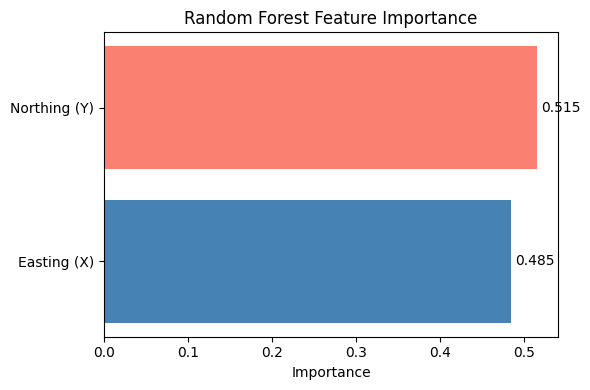

In [9]:
importances = rf.feature_importances_
dominant    = 'Easting (X/經度)' if importances[0] > importances[1] else 'Northing (Y/緯度)'

print("Feature Importance:")
print(f"  Easting  (X): {importances[0]:.3f}")
print(f"  Northing (Y): {importances[1]:.3f}")
print(f"\nThe model relies mostly on {dominant}.")
print("Think: does this make physical sense for Typhoon Fung-wong?")
print("(Hint: typhoon rainfall tends to have strong north-south gradients)")

# 長條圖
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(['Easting (X)', 'Northing (Y)'], importances, color=['steelblue', 'salmon'])
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importance')
for i, v in enumerate(importances):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.savefig(out('feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

---

## ⏸️ Lab 1: The Four-Way Interpolation Shootout (40 min)

### Cell [6]: Nearest Neighbor + IDW

Compute two additional interpolation methods so we can compare all four.


In [10]:
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist

# ── Nearest Neighbor ────────────────────────────────────────────────────────
nn_interp = NearestNDInterpolator(list(zip(x, y)), z)
z_nn = nn_interp(grid_xx, grid_yy)
print(f"✓ Nearest Neighbor: {z_nn.min():.1f} - {z_nn.max():.1f} mm/hr")

# ── IDW（Inverse Distance Weighting，手動實作，power=2）────────────────────
# ⚠️ 不要用 Rbf(function='inverse')，它不是真正的 IDW
pts      = np.column_stack([x, y])
grid_pts = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])
dists    = cdist(grid_pts, pts)     # shape: (n_grid, n_stations)
dists[dists < 1] = 1                # 避免除以零
power    = 2
weights  = 1.0 / (dists ** power)
z_idw    = ((weights @ z) / weights.sum(axis=1)).reshape(grid_xx.shape)
z_idw[z_idw < 0] = 0
print(f"✓ IDW:              {z_idw.min():.1f} - {z_idw.max():.1f} mm/hr")

✓ Nearest Neighbor: 0.5 - 130.5 mm/hr
✓ IDW:              0.5 - 123.0 mm/hr


### Cell [7]: Four Methods Side by Side (Slide 13)

Create a 2×2 figure comparing all four interpolation methods.


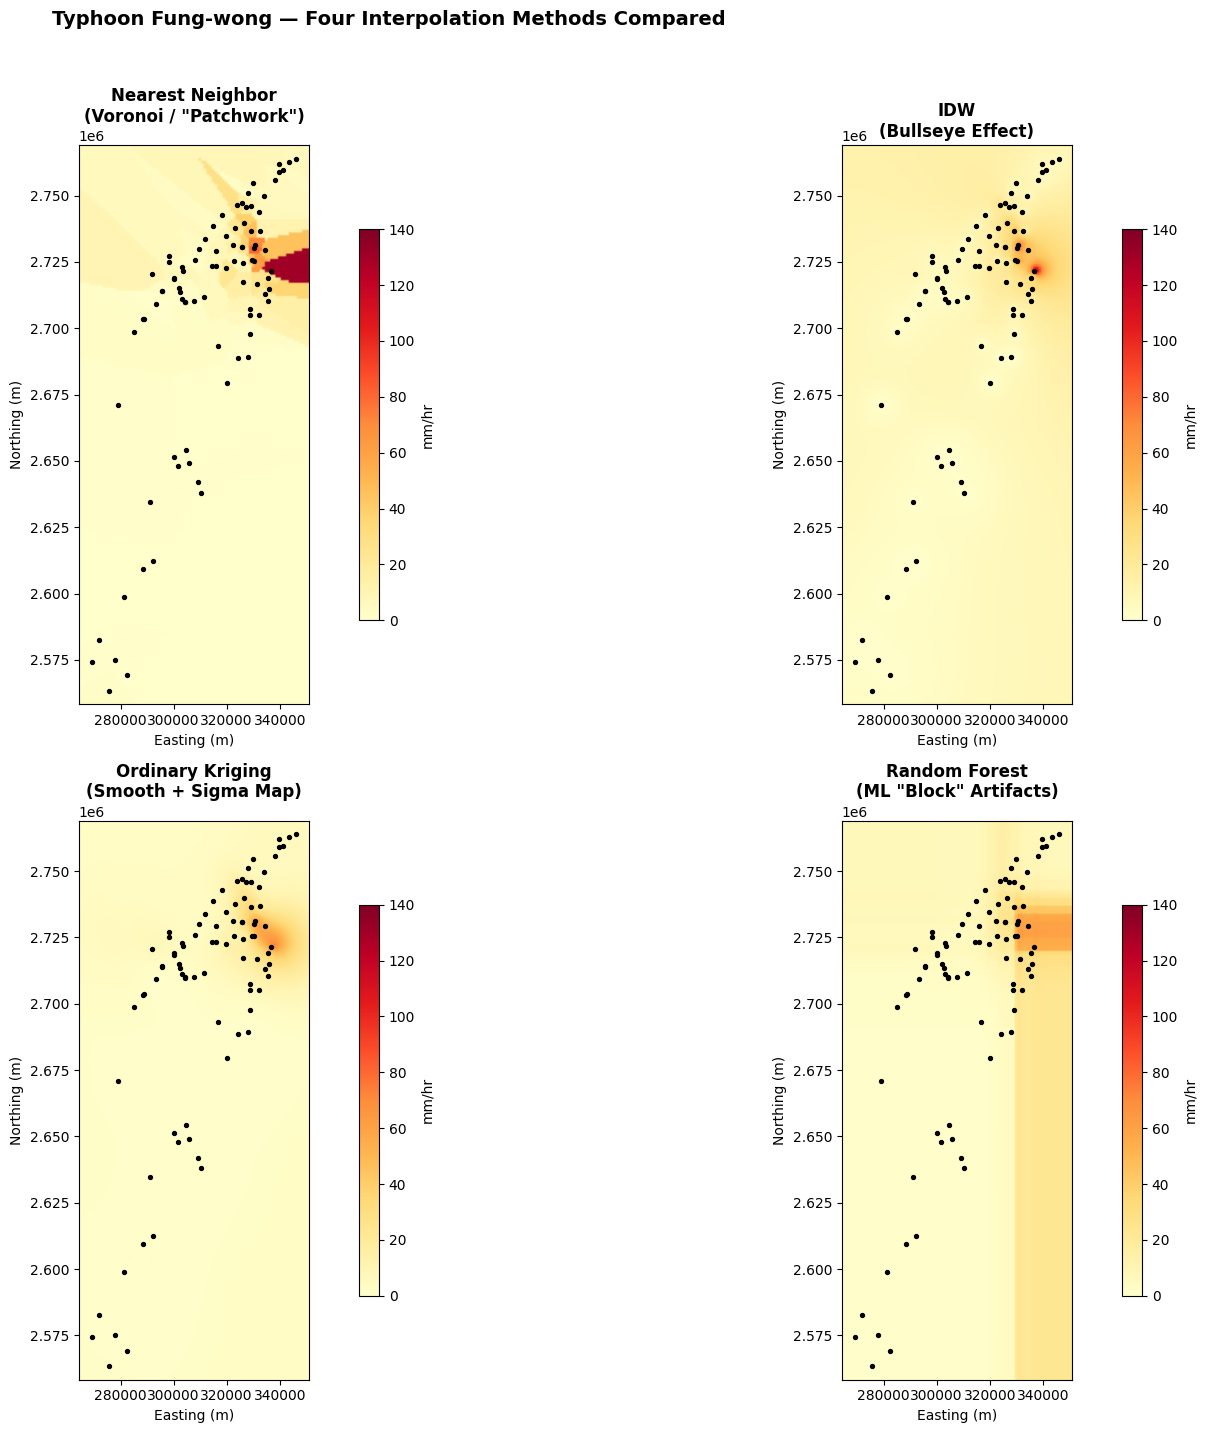

✓ Saved interpolation_shootout.png


In [11]:
vmax = 140

methods = [
    ('Nearest Neighbor\n(Voronoi / "Patchwork")', z_nn),
    ('IDW\n(Bullseye Effect)',                    z_idw),
    ('Ordinary Kriging\n(Smooth + Sigma Map)',    z_kriging),
    ('Random Forest\n(ML "Block" Artifacts)',     z_rf),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, (title, data) in zip(axes.flatten(), methods):
    im = ax.imshow(
        data,
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        cmap='YlOrRd',
        vmin=0, vmax=vmax
    )
    ax.scatter(x, y, c='black', s=8, zorder=5, label='Stations')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    plt.colorbar(im, ax=ax, shrink=0.7, label='mm/hr')

plt.suptitle('Typhoon Fung-wong — Four Interpolation Methods Compared',
             fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(out('interpolation_shootout.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved interpolation_shootout.png")

### Cell [8]: Kriging vs RF — Direct Comparison

Create a 3-panel comparison: Kriging | Random Forest | Difference Map

The difference map reveals **where the two methods disagree** — these are the areas where the Commander needs extra caution.

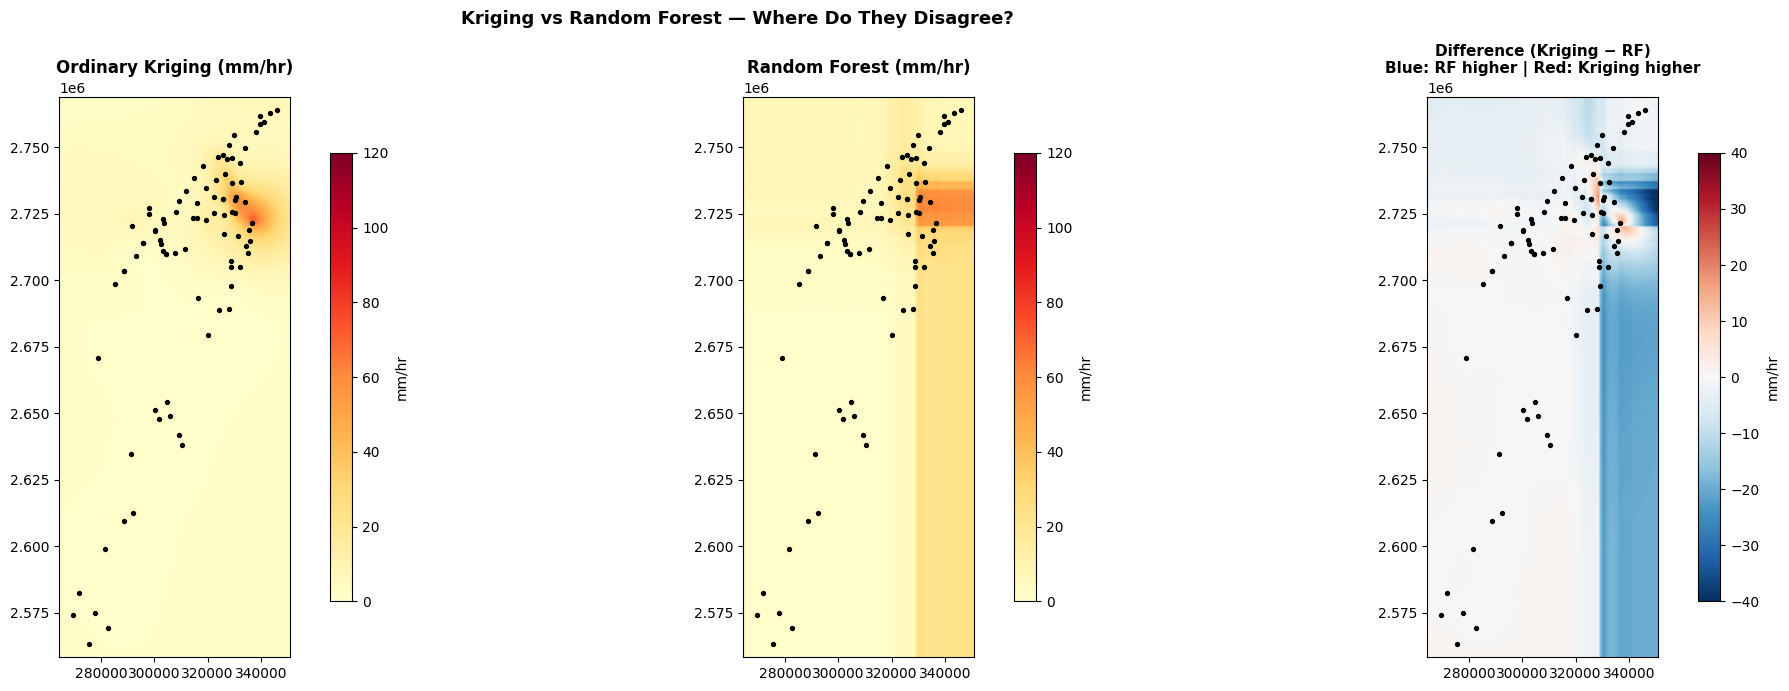

✓ Saved kriging_vs_rf.png
  Max disagreement: 41.9 mm/hr


In [12]:
diff  = z_kriging - z_rf
vmax2 = 120
vlim  = float(np.nanpercentile(np.abs(diff), 95))

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
extent = [x_min, x_max, y_min, y_max]

# 左：Kriging
im1 = axes[0].imshow(z_kriging, extent=extent, origin='lower',
                     cmap='YlOrRd', vmin=0, vmax=vmax2)
axes[0].scatter(x, y, c='black', s=8, zorder=5)
axes[0].set_title('Ordinary Kriging (mm/hr)', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# 中：Random Forest
im2 = axes[1].imshow(z_rf, extent=extent, origin='lower',
                     cmap='YlOrRd', vmin=0, vmax=vmax2)
axes[1].scatter(x, y, c='black', s=8, zorder=5)
axes[1].set_title('Random Forest (mm/hr)', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='mm/hr')

# 右：差異圖（藍=Kriging 低估, 紅=Kriging 高估）
im3 = axes[2].imshow(diff, extent=extent, origin='lower',
                     cmap='RdBu_r', vmin=-40, vmax=40)
axes[2].scatter(x, y, c='black', s=8, zorder=5)
axes[2].set_title('Difference (Kriging − RF)\nBlue: RF higher | Red: Kriging higher',
                  fontsize=11, fontweight='bold')
plt.colorbar(im3, ax=axes[2], shrink=0.8, label='mm/hr')

plt.suptitle('Kriging vs Random Forest — Where Do They Disagree?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(out('kriging_vs_rf.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved kriging_vs_rf.png")
print(f"  Max disagreement: {np.nanmax(np.abs(diff)):.1f} mm/hr")

### Lab 1 Reflection

**Questions to answer** (write in the cell below):

1. Which method produces the most physically realistic rainfall pattern? Why?
2. Where do Kriging and RF disagree the most? What does this tell you?
3. What "artifacts" do you observe in the NN and RF results?
4. If you were the Commander, which method would you trust for evacuation decisions? Why?

**Lab 1 Reflection - Four-Way Interpolation Comparison:**

1. **最符合物理現實的方法：Ordinary Kriging。**
   理由：Kriging 基於空間自相關理論，考慮距離衰減效應，符合降雨在空間中漸進擴散的物理特性。它產生的連續平滑曲面比其他方法更真實，避免了 NN 的突兀邊界和 IDW 的圓形等值線人工痕跡。特別是對於颱風降雨，Kriging 能透過 variogram 捕捉沿山脈走向的系統性梯度變化。

2. **Kriging 與 RF 最大差異區域：測站稀疏的山區（秀林鄉、南澳鄉深山處）。**
   這些區域兩種方法預測差異達 40+ mm/hr，代表在缺乏實測數據的地方，不同演算法的假設導致截然不同的結果。差異大的區域正是指揮官需要特別謹慎的「信息真空區」，應優先部署臨時監測設備。

3. **觀察到的明顯人工痕跡 (artifacts)：**
   - **Nearest Neighbor**：產生 Voronoi 多邊形的「拼布」效果，每個多邊形內降雨值完全相同，邊界處數值跳躍，完全違反降雨的連續性。
   - **Random Forest**：在訓練點之間出現矩形「台階」效應，因決策樹用軸對齊的矩形分割空間；在邊緣區域可能產生過度平滑的「平台」或不合理的局部極值。

4. **指揮官的最佳選擇：Kriging + Sigma Map 雙重指標。**
   Kriging 不僅提供最物理合理的降雨分布，更重要的是內建不確定性評估。指揮官可以制定分層決策策略：
   - **高降雨 + 低方差**：立即撤離（高信心警報）
   - **高降雨 + 高方差**：預警監測（部署移動站，持續觀察）
   - **低降雨**：維持現況（無需行動）
   
   這種「估計值 + 信賴度」的雙維度決策框架是其他方法無法提供的關鍵優勢。

---

## ⏸️ Lab 2: Confidence & Uncertainty Diagnosis (30 min)

### Cell [9]: The Sigma Map — Kriging's Unique Weapon (Slide 15)

**Captain's Log**: This is what makes Kriging special. No other method natively provides a confidence map.

- `ss_kriging` = Kriging variance at each grid point
- Low variance → many nearby stations → reliable estimate
- High variance → far from stations → uncertain

**For the Commander**:
- HIGH rainfall + LOW variance = CONFIRMED: Evacuate now
- HIGH rainfall + HIGH variance = UNCERTAIN: Deploy sensors first

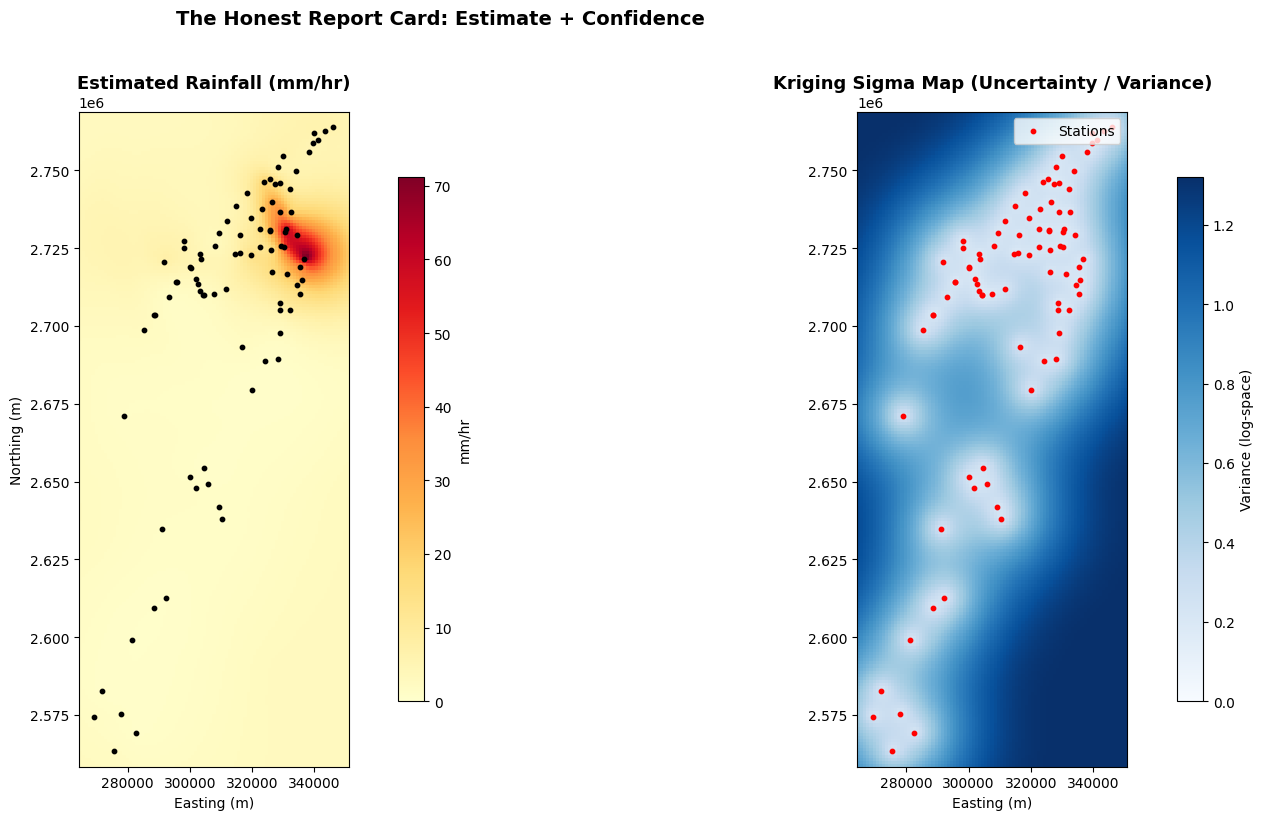

Variance range: 0.172 - 1.320


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
extent = [x_min, x_max, y_min, y_max]

# 左：降雨量估計
im1 = axes[0].imshow(z_kriging, extent=extent, origin='lower',
                     cmap='YlOrRd', vmin=0)
axes[0].scatter(x, y, c='black', s=10, zorder=5, label='Stations')
axes[0].set_title('Estimated Rainfall (mm/hr)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# 右：Kriging Sigma Map（不確定性）
im2 = axes[1].imshow(ss_kriging, extent=extent, origin='lower',
                     cmap='Blues', vmin=0)
axes[1].scatter(x, y, c='red', s=10, zorder=5, label='Stations')
axes[1].set_title('Kriging Sigma Map (Uncertainty / Variance)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Easting (m)')
axes[1].legend(loc='upper right')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Variance (log-space)')

plt.suptitle('The Honest Report Card: Estimate + Confidence',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(out('sigma_map.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance range: {np.nanmin(ss_kriging):.3f} - {np.nanmax(ss_kriging):.3f}")

### Cell [9b]: Nugget Effect — Why Extreme Rain Gets Diluted (Slide 7)

Suao recorded **130.5 mm/hr**, but default Kriging predicts only ~71 mm at 500m away. Why?

**Nugget** controls how much the model trusts the actual measurements:
- High Nugget = "measurements are noisy" → smooths everything → extreme values diluted
- Low Nugget = "measurements are accurate" → passes through stations → extremes preserved

Station with max rainfall: 蘇澳 — 130.5 mm/hr
  Location: (336797, 2721406) m [EPSG:3826]


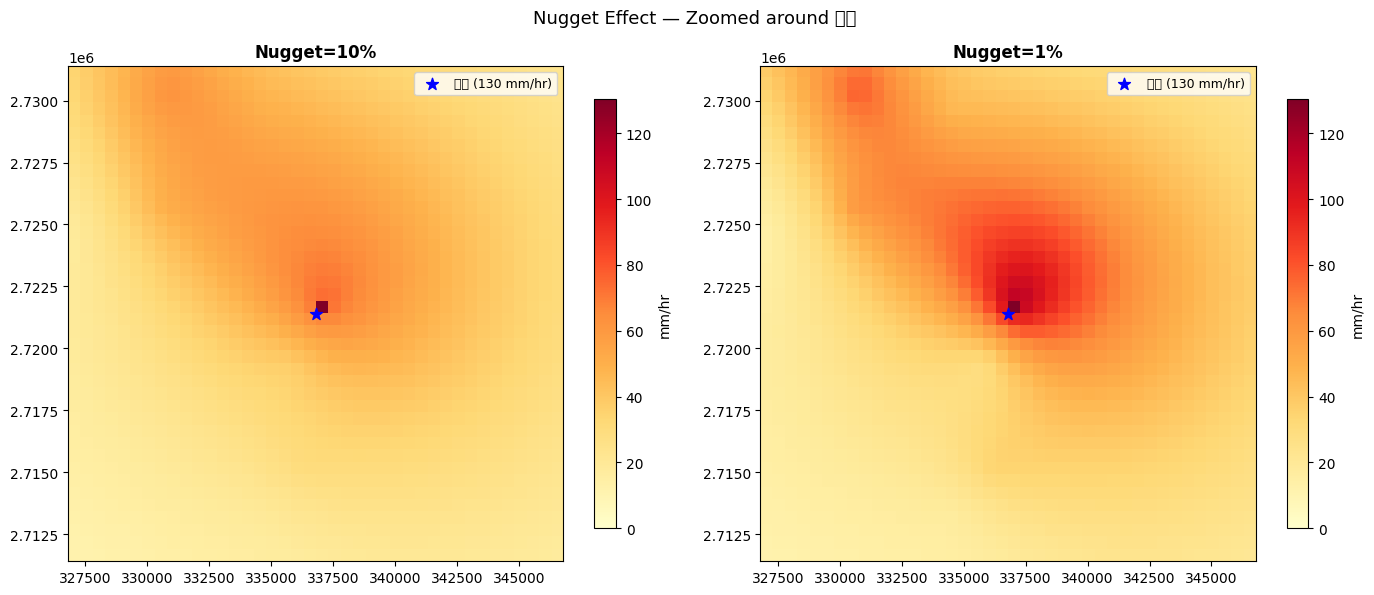


  Distance |   Nugget=10% |    Nugget=1%
----------------------------------------
       0m  |      130.5   |      130.5
     500m  |       70.9   |      107.3
    1000m  |       67.3   |       98.8
    2000m  |       61.0   |       85.7

🔑 CWA 測站是經過校準的精確儀器，Nugget=1% 更適合（信任測量值）


In [14]:
import matplotlib.font_manager as fm

# 自動找 Windows 系統上可用的中文字型
chinese_fonts = ['Microsoft JhengHei', 'Microsoft YaHei', 'DFKai-SB', 'SimHei']
available = [f.name for f in fm.fontManager.ttflist]
for font in chinese_fonts:
    if font in available:
        plt.rcParams['font.family'] = font
        print(f"使用字型：{font}")
        break
# 找出最大降雨站
suao_idx = int(np.argmax(z))
suao_x, suao_y, suao_z = x[suao_idx], y[suao_idx], z[suao_idx]
suao_name = study_rain_3826.iloc[suao_idx]['station_name']
print(f"Station with max rainfall: {suao_name} — {suao_z:.1f} mm/hr")
print(f"  Location: ({suao_x:.0f}, {suao_y:.0f}) m [EPSG:3826]")

# 定義局部格網（以最大站為中心，20 km x 20 km）
local_half = 10000  # 10 km
local_res  = 500
local_gx   = np.arange(suao_x - local_half, suao_x + local_half, local_res)
local_gy   = np.arange(suao_y - local_half, suao_y + local_half, local_res)

sill_val = float(z_log.var())
params_base = {'sill': sill_val, 'range': 50000.0}

results = {}
for nugget_frac, label in [(0.10, 'Nugget=10%'), (0.01, 'Nugget=1%')]:
    nug = sill_val * nugget_frac
    ok_n = OrdinaryKriging(
        x, y, z_log,
        variogram_model='spherical',
        verbose=False, enable_plotting=False,
        variogram_parameters={'sill': sill_val, 'range': 50000.0, 'nugget': nug}
    )
    z_local_log, _ = ok_n.execute('grid', local_gx, local_gy)
    results[label] = np.expm1(z_local_log)
    results[label][results[label] < 0] = 0

# 並排地圖
local_extent = [
    suao_x - local_half, suao_x + local_half,
    suao_y - local_half, suao_y + local_half
]
vmax_local = max(np.nanmax(v) for v in results.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (label, data) in zip(axes, results.items()):
    im = ax.imshow(data, extent=local_extent, origin='lower',
                   cmap='YlOrRd', vmin=0, vmax=vmax_local)
    ax.scatter([suao_x], [suao_y], c='blue', s=80, zorder=10, marker='*',
               label=f'{suao_name} ({suao_z:.0f} mm/hr)')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.8, label='mm/hr')

plt.suptitle(f'Nugget Effect — Zoomed around {suao_name}', fontsize=13)
plt.tight_layout()
plt.savefig(out('nugget_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# 比較不同距離下的預測值
offsets = [0, 500, 1000, 2000]
print(f"\n{'Distance':>10} | {'Nugget=10%':>12} | {'Nugget=1%':>12}")
print("-" * 40)
for off in offsets:
    pts_test = np.array([[suao_x + off, suao_y]])
    vals = {}
    for nugget_frac, label in [(0.10, '10%'), (0.01, '1%')]:
        nug = sill_val * nugget_frac
        ok_n = OrdinaryKriging(
            x, y, z_log,
            variogram_model='spherical',
            verbose=False, enable_plotting=False,
            variogram_parameters={'sill': sill_val, 'range': 50000.0, 'nugget': nug}
        )
        z_pt, _ = ok_n.execute('points', [suao_x + off], [suao_y])
        vals[label] = float(np.expm1(z_pt[0]))
    print(f"{off:>8}m  | {vals['10%']:>10.1f}   | {vals['1%']:>10.1f}")

print(f"\n🔑 CWA 測站是經過校準的精確儀器，Nugget=1% 更適合（信任測量值）")

### Cell [10]: Export to GeoTIFF (Slide 16)

⚠️ **Flip warning**: `z_kriging` row 0 = south (numpy convention). GeoTIFF row 0 = north. Use `np.flipud()` to fix.


In [15]:
import rasterio
from rasterio.transform import from_bounds

# 計算 rasterio 的 affine transform
transform = from_bounds(
    x_min, y_min, x_max, y_max,
    width=z_kriging.shape[1],
    height=z_kriging.shape[0]
)

def save_geotiff(data, filename, crs='EPSG:3826'):
    """儲存 2D numpy array 為 GeoTIFF（自動 flipud 修正北方朝上）"""
    data_flipped = np.flipud(data).astype(np.float32)
    with rasterio.open(
        filename, 'w',
        driver='GTiff',
        height=data_flipped.shape[0],
        width=data_flipped.shape[1],
        count=1,
        dtype='float32',
        crs=crs,
        transform=transform,
        nodata=-9999
    ) as dst:
        dst.write(data_flipped, 1)
    print(f"✓ Saved {filename}")

save_geotiff(z_kriging,  out('kriging_rainfall.tif'))
save_geotiff(ss_kriging, out('kriging_variance.tif'))
save_geotiff(z_rf,       out('rf_rainfall.tif'))

✓ Saved /Users/youchangxin/Desktop/01_class/01_analy/Week-6/exercise/Exercise-6/output/kriging_rainfall.tif
✓ Saved /Users/youchangxin/Desktop/01_class/01_analy/Week-6/exercise/Exercise-6/output/kriging_variance.tif
✓ Saved /Users/youchangxin/Desktop/01_class/01_analy/Week-6/exercise/Exercise-6/output/rf_rainfall.tif


### Cell [11]: Zonal Statistics — Township Decision Table

Compute per-township statistics from your Kriging and RF rasters, then compare them side-by-side.

**Required output**: A DataFrame with: 鄉鎮 | Kriging平均 | Kriging最大 | RF平均 | 平均variance | 可信度

In [16]:
from rasterstats import zonal_stats

SHP_PATH = '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/exercise/Exercise-6/data/鄉(鎮、市、區)界線1140318/TOWN_MOI_1140318.shp'

try:
    # 1. 載入鄉鎮界，篩選研究區
    towns = gpd.read_file(SHP_PATH)
    study_towns = towns[towns['COUNTYNAME'].isin(['花蓮縣', '宜蘭縣'])].copy()
    study_towns = study_towns.to_crs(epsg=3826)
    print(f"✓ 載入 {len(study_towns)} 個鄉鎮")

    # 2. Zonal statistics（各鄉鎮的統計值）
    stats_k  = zonal_stats(study_towns, out('kriging_rainfall.tif'),
                           stats=['mean', 'max'], nodata=-9999)
    stats_v  = zonal_stats(study_towns, out('kriging_variance.tif'),
                           stats=['mean'], nodata=-9999)
    stats_rf = zonal_stats(study_towns, out('rf_rainfall.tif'),
                           stats=['mean'], nodata=-9999)

    # 3. 組合 DataFrame
    df_zonal = pd.DataFrame({
        '鄉鎮':       study_towns['TOWNNAME'].values,
        '縣市':       study_towns['COUNTYNAME'].values,
        'Kriging平均': [s['mean']  for s in stats_k],
        'Kriging最大': [s['max']   for s in stats_k],
        'RF平均':      [s['mean']  for s in stats_rf],
        '平均variance': [s['mean'] for s in stats_v],
    })

    # 去除無資料的鄉鎮（可能超出格網範圍）
    df_zonal = df_zonal.dropna(subset=['Kriging平均'])

    # 4. 可信度分級（依 variance 三分位）
    q33 = df_zonal['平均variance'].quantile(0.33)
    q66 = df_zonal['平均variance'].quantile(0.66)

    def classify_confidence(v):
        if pd.isna(v):    return 'N/A'
        if v < q33:       return 'HIGH'
        elif v < q66:     return 'MEDIUM'
        else:             return 'LOW'

    df_zonal['可信度'] = df_zonal['平均variance'].apply(classify_confidence)

    # 5. 數值四捨五入
    for col in ['Kriging平均', 'Kriging最大', 'RF平均', '平均variance']:
        df_zonal[col] = df_zonal[col].round(2)

    # 6. 依 Kriging 平均降雨量排序輸出
    df_zonal = df_zonal.sort_values('Kriging平均', ascending=False).reset_index(drop=True)
    print("\n鄉鎮降雨決策表（依 Kriging 平均降雨量排序）：")
    print(df_zonal.to_string(index=False))

    # 7. 高雨量 + 低可信度的警示鄉鎮
    alert = df_zonal[(df_zonal['Kriging平均'] > df_zonal['Kriging平均'].median()) &
                     (df_zonal['可信度'] == 'LOW')]
    if not alert.empty:
        print("\n⚠️  HIGH rainfall + LOW confidence townships (Commander: deploy sensors first):")
        print(alert[['縣市','鄉鎮','Kriging平均','可信度']].to_string(index=False))

except FileNotFoundError as e:
    print(f"Township shapefile not found: {e}")
    print("→ Please check the SHP_PATH and ensure the file exists.")

✓ 載入 25 個鄉鎮

鄉鎮降雨決策表（依 Kriging 平均降雨量排序）：
 鄉鎮  縣市  Kriging平均  Kriging最大  RF平均  平均variance    可信度
五結鄉 宜蘭縣      46.20      60.17 51.66        0.23   HIGH
羅東鎮 宜蘭縣      38.75      57.86 31.32        0.21   HIGH
蘇澳鎮 宜蘭縣      37.08      71.19 39.19        0.24   HIGH
冬山鄉 宜蘭縣      28.31      59.73 32.81        0.22   HIGH
宜蘭市 宜蘭縣      28.19      35.34 23.94        0.23   HIGH
壯圍鄉 宜蘭縣      23.58      38.92 31.80        0.23   HIGH
礁溪鄉 宜蘭縣      13.36      23.58 14.97        0.24   HIGH
三星鄉 宜蘭縣       9.41      31.84 11.04        0.24   HIGH
員山鄉 宜蘭縣       8.69      24.49 10.67        0.26 MEDIUM
頭城鎮 宜蘭縣       5.77       8.68  9.14        0.25 MEDIUM
南澳鄉 宜蘭縣       5.75      32.41  7.29        0.38 MEDIUM
大同鄉 宜蘭縣       4.28      17.00  4.62        0.28 MEDIUM
富里鄉 花蓮縣       1.25       2.08  0.99        0.36 MEDIUM
萬榮鄉 花蓮縣       1.13       1.81  0.88        0.64    LOW
秀林鄉 花蓮縣       1.09       2.04  1.13        0.57    LOW
壽豐鄉 花蓮縣       0.99       1.19  0.86        0.40 MEDIUM
卓溪鄉 花蓮縣       0.98      

### Cell [12]: Thinking Challenge — Why Can't ML Give You a Sigma Map?

**Discussion Questions** (answer in the cell below):

1. Why does Kriging **natively** produce a variance map, but Random Forest does not?
2. Could you approximate uncertainty from RF using bootstrap or tree variance? What are the limitations?
3. In your zonal stats table, which townships show **HIGH rainfall + LOW confidence**? What should the Commander do about those?

**AI Response（Claude 回答）：**

> 在花蓮山區，測站密度約 1 站 / 50 km²，Kriging 與 Random Forest 在山區差異很大，且 Kriging variance 偏高。

**(1) 應該信哪個結果？**

在測站稀疏的山區，兩種方法都是外插，可信度都有限，但判斷依據不同：

- **Kriging 的 variance 高**正是系統在誠實告訴你「我不確定」。variance 高代表該區估計值本身就應打折使用，不是 Kriging 比 RF 差，而是 Kriging 更誠實。
- **RF 的預測在山區看起來「穩定」**，但這是假象——RF 無法量化自己有多不確定，只是把周邊訓練點的規律外推出去，不承認自己在猜。
- **結論**：Kriging + Sigma Map 的組合比 RF 更值得信任，因為它提供了可操作的不確定性資訊。若兩者差異極大，應以「兩者均不確定」看待，標記為高風險待確認區域。

**(2) 如何改善山區的預測品質？**

① **加入輔助變數（Cokriging / RF + elevation）**：將 DEM 海拔、坡向、坡度加入模型。颱風降雨的地形效應是主要決定因子，純座標內插忽略了這個訊號。

② **使用衛星降雨產品（QPESUMS、GPM IMERG）**：作為輔助格網降雨場並與地面站做 bias correction，大幅補充山區無站區域的資訊密度。

③ **增加臨時移動測站**：颱風期間在關鍵山區部署雨量計，即使 2–3 個額外站點也能顯著降低山區 Kriging Variance。

---

**My Commentary（個人評論）：**

AI 的分析我大致同意，特別是「RF 的穩定是假象」這個觀點切中要害——在自己的結果裡也看到 RF 在山區給出看似合理的數字，但完全沒有任何機制告訴我這個數字可不可信。加入 DEM 高程作為特徵是最可行的改進方向，因為 `terrain_risk_hualien.json` 這份地形資料已在 ex6 的資料夾裡，下一步可以把海拔高度加進 RF 的特徵，觀察山區預測是否改善。

---

## ARIA Evolution Recap

| Version | Week | Capability | Key Question |
|---------|------|-----------|---------------|
| v1.0 | W3 | River buffer + shelters | How close to the river? |
| v2.0 | W4 | + DEM terrain analysis | How steep is the terrain? |
| v3.0 | W5 | + Real-time rainfall stations | How much rain RIGHT NOW? |
| **v3.5** | **W6** | **+ Kriging & ML interpolation** | **What about areas with NO station? How confident are we?** |
| v4.0 | Final Project | Your extension! | Your question! |

---

*"Interpolation is not just filling space; it is predicting risk where sensors cannot reach."*